**CHATGPT REVIEW ANALYSIS**

In [ ]:
import pandas as pd
import re

Data Cleaning And Preprocessing

In [ ]:

df = pd.read_csv("/content/drive/MyDrive/chatgpt_reviews.csv")


#Standardized Columns
df.columns = df.columns.str.lower().str.replace(' ', '_')

#Fill Missing Values
df['review'] = df['review'].fillna("No Review")

#Convert Rating to Numeric
df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce')

#Remove Duplicates
df = df.drop_duplicates()
df['review_date'] = pd.to_datetime(df['review_date'])



df['clean_review'] = df['review'].str.lower()
df['clean_review'] = df['clean_review'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x))

Sensititvity Analysis

In [ ]:
from textblob import TextBlob
import nltk
nltk.download('punkt')
nltk.download('stopwords')
!python -m textblob.download_corpora

df['polarity'] = df['clean_review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['clean_review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)


def sentiment_category(score):
  if score > 0:
    return 'Positive'
  elif score < 0:
    return 'Negative'
  else:
    return 'Neutral'

df['sentiment'] = df['polarity'].apply(sentiment_category)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


Text Analysis

In [ ]:
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

def frequent_words(df):
  text = " ".join(df['clean_review'])
  words = text.split()
  word_counts = Counter(words)
  return word_counts.most_common(10)

In [ ]:
def tfidf_keywords(df):
  vectorizor = TfidfVectorizer(max_features = 20)
  X = vectorizor.fit_transform(df['clean_review'])
  return vectorizor.get_feature_names_out()


Visualizations

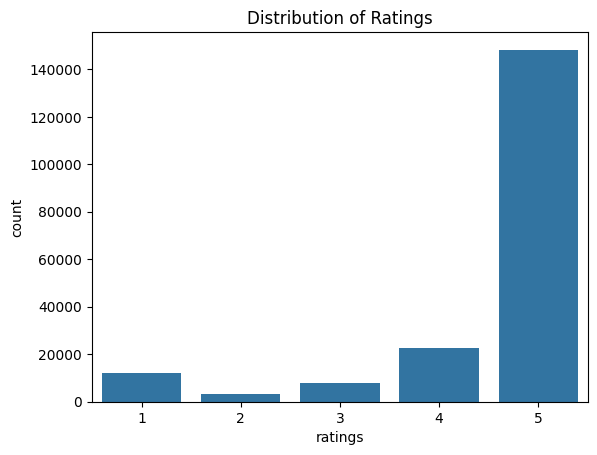

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import pandas as pd
import os

# Create the directory if it doesn't exist
os.makedirs('outputs/charts/', exist_ok=True)

#Ratings Distrbution
plt.figure()
sns.countplot(x='ratings', data=df)
plt.title("Distribution of Ratings")
plt.savefig("outputs/charts/rating_distribution.png")
plt.show()

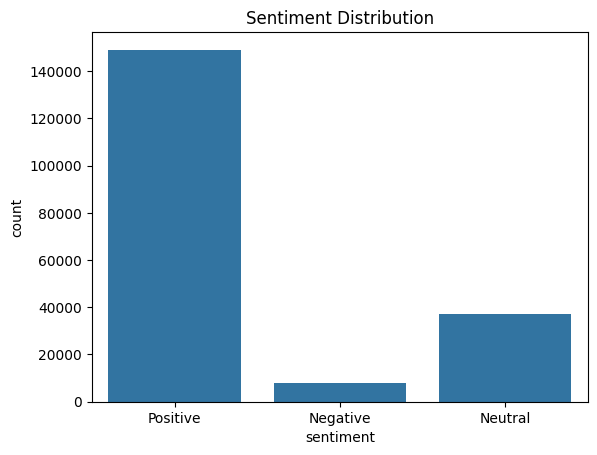

In [ ]:
#Sentiment Distribution
plt.figure()
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.savefig("outputs/charts/sentiment_distribution.png")
plt.show()

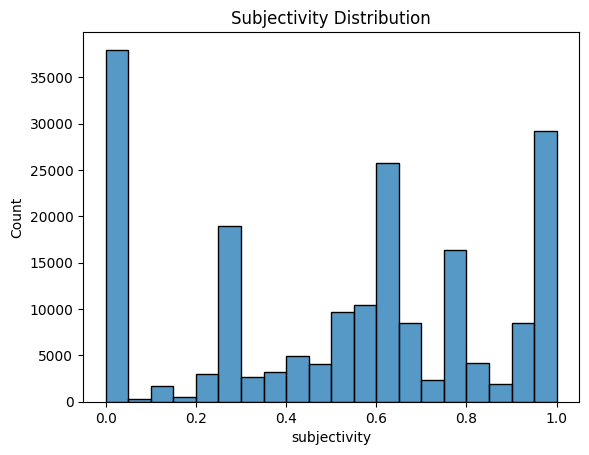

In [ ]:
#Subjectivity Distribution (0 for Factual/Objective and 1 for subjective/opinnionated)
plt.figure()
sns.histplot(df['subjectivity'], bins=20)
plt.title("Subjectivity Distribution")
plt.savefig("outputs/charts/subjectivity_distribution.png")
plt.show()


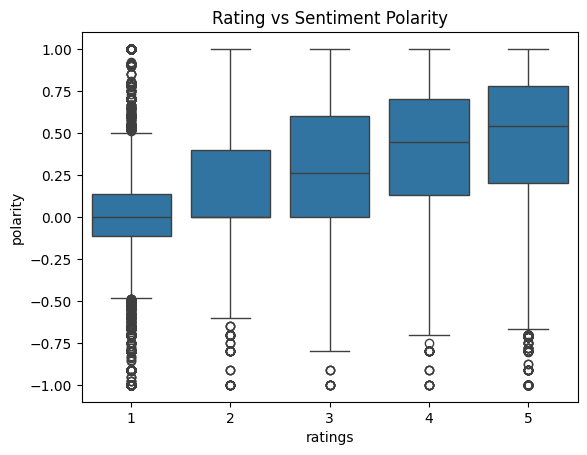

In [ ]:
#Ratings Vs Sesntiment Polarity
plt.figure()
sns.boxplot(x='ratings', y='polarity', data=df)
plt.title("Rating vs Sentiment Polarity")
plt.savefig("outputs/charts/rating_vs_sentiment.png")
plt.show()

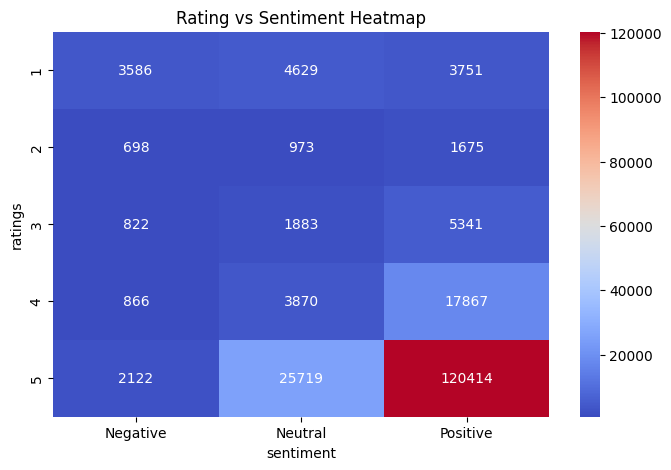

In [ ]:
#Ratings Vs Sentiment Heatmap
sentiment_rating = pd.crosstab(df['ratings'], df['sentiment'])
plt.figure(figsize=(8,5))
sns.heatmap(sentiment_rating, annot=True, cmap="coolwarm", fmt="d")
plt.title("Rating vs Sentiment Heatmap")
plt.savefig("outputs/charts/rating_vs_sentiment_heatmap.png")
plt.show()

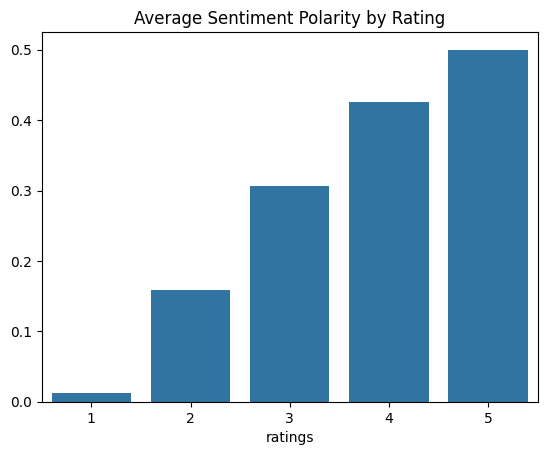

In [ ]:
#Average Sentiment By Rating
avg_sentiment = df.groupby('ratings')['polarity'].mean()
plt.figure()
sns.barplot(x=avg_sentiment.index, y=avg_sentiment.values)
plt.title("Average Sentiment Polarity by Rating")
plt.savefig("outputs/charts/average_sentiment_by_rating.png")
plt.show()

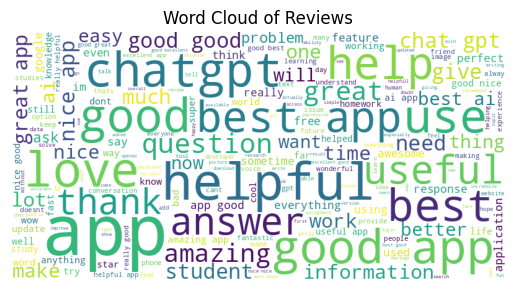

In [ ]:
#Word Cloud
text = " ".join(df['clean_review'])
wc = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.figure()
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.savefig("outputs/charts/word_cloud.png")
plt.show()

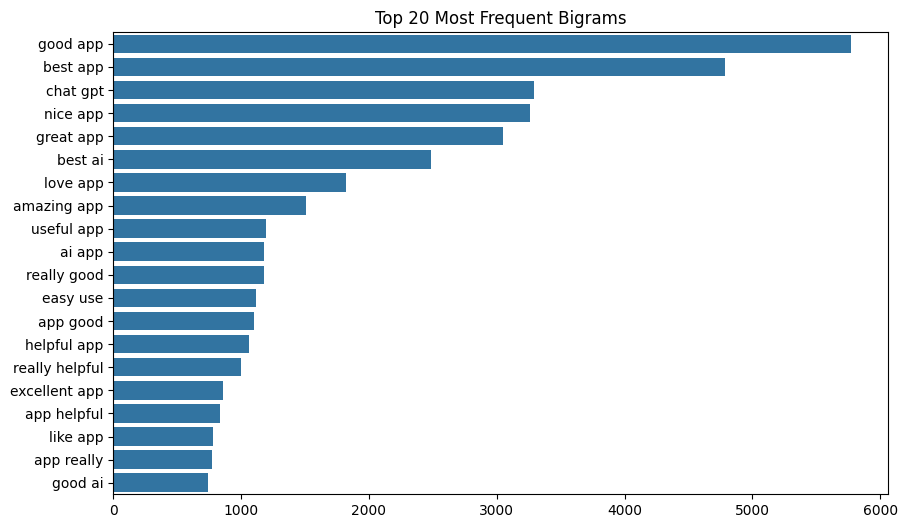

In [ ]:
#Bigram Analysis
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X = vectorizer.fit_transform(df['clean_review'])
bigram_counts = np.sum(X.toarray(), axis=0)
bigrams = vectorizer.get_feature_names_out()
bigram_freq = sorted(
zip(bigrams, bigram_counts),
key=lambda x: x[1],
reverse=True
)[:20]
words = [i[0] for i in bigram_freq]
counts = [i[1] for i in bigram_freq]
plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Most Frequent Bigrams")
plt.savefig("outputs/charts/top_20_bigrams.png")
plt.show()

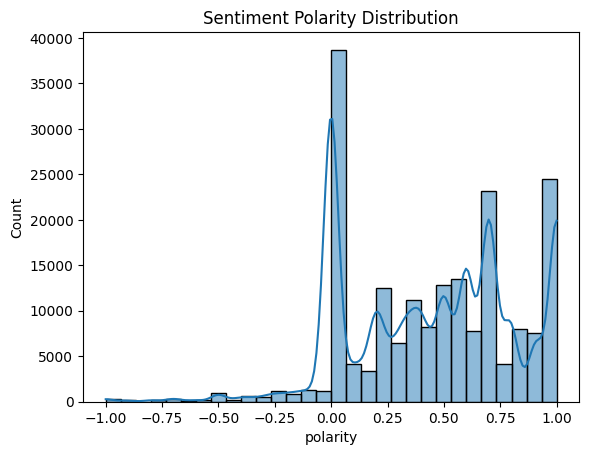

In [ ]:
#Polarity Distribution
plt.figure()
sns.histplot(df['polarity'], bins=30, kde=True)
plt.title("Sentiment Polarity Distribution")
plt.savefig("outputs/charts/sentiment_polarity_distribution.png")
plt.show()

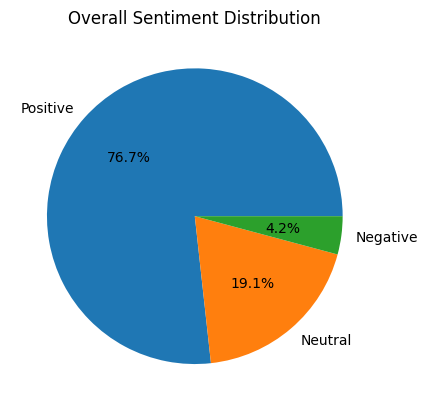

In [ ]:
#Sentiment Pie Chart
sentiment_counts = df['sentiment'].value_counts()
plt.figure()
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%')
plt.title("Overall Sentiment Distribution")
plt.savefig("outputs/charts/overall_sentiment_distribution.png")
plt.show()